In [1]:
# Source: https://medium.com/@datasciencewizards/end-to-end-logistic-regression-modelling-55e5d8bb1156

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
data = pd.read_csv('https://raw.githubusercontent.com/TarekDib03/Analytics/master/Week3%20-%20Logistic%20Regression/Data/framingham.csv')

In [3]:
data.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
data.diabetes.value_counts()

diabetes
0    4131
1     109
Name: count, dtype: int64

In [5]:
data.TenYearCHD.value_counts()

TenYearCHD
0    3596
1     644
Name: count, dtype: int64

In [6]:
data['male'] = data['male'].map({1:'male', 0:'female'})
data.rename(columns = {'male':'Sex'}, inplace = True)

In [7]:
# Data Exploration

In [8]:
print('shape of the data', data.shape)

shape of the data (4240, 16)


In [9]:
data.describe()

,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [10]:
import missingno as ms

In [11]:
data.isna().sum()

Sex                  0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

<Axes: >

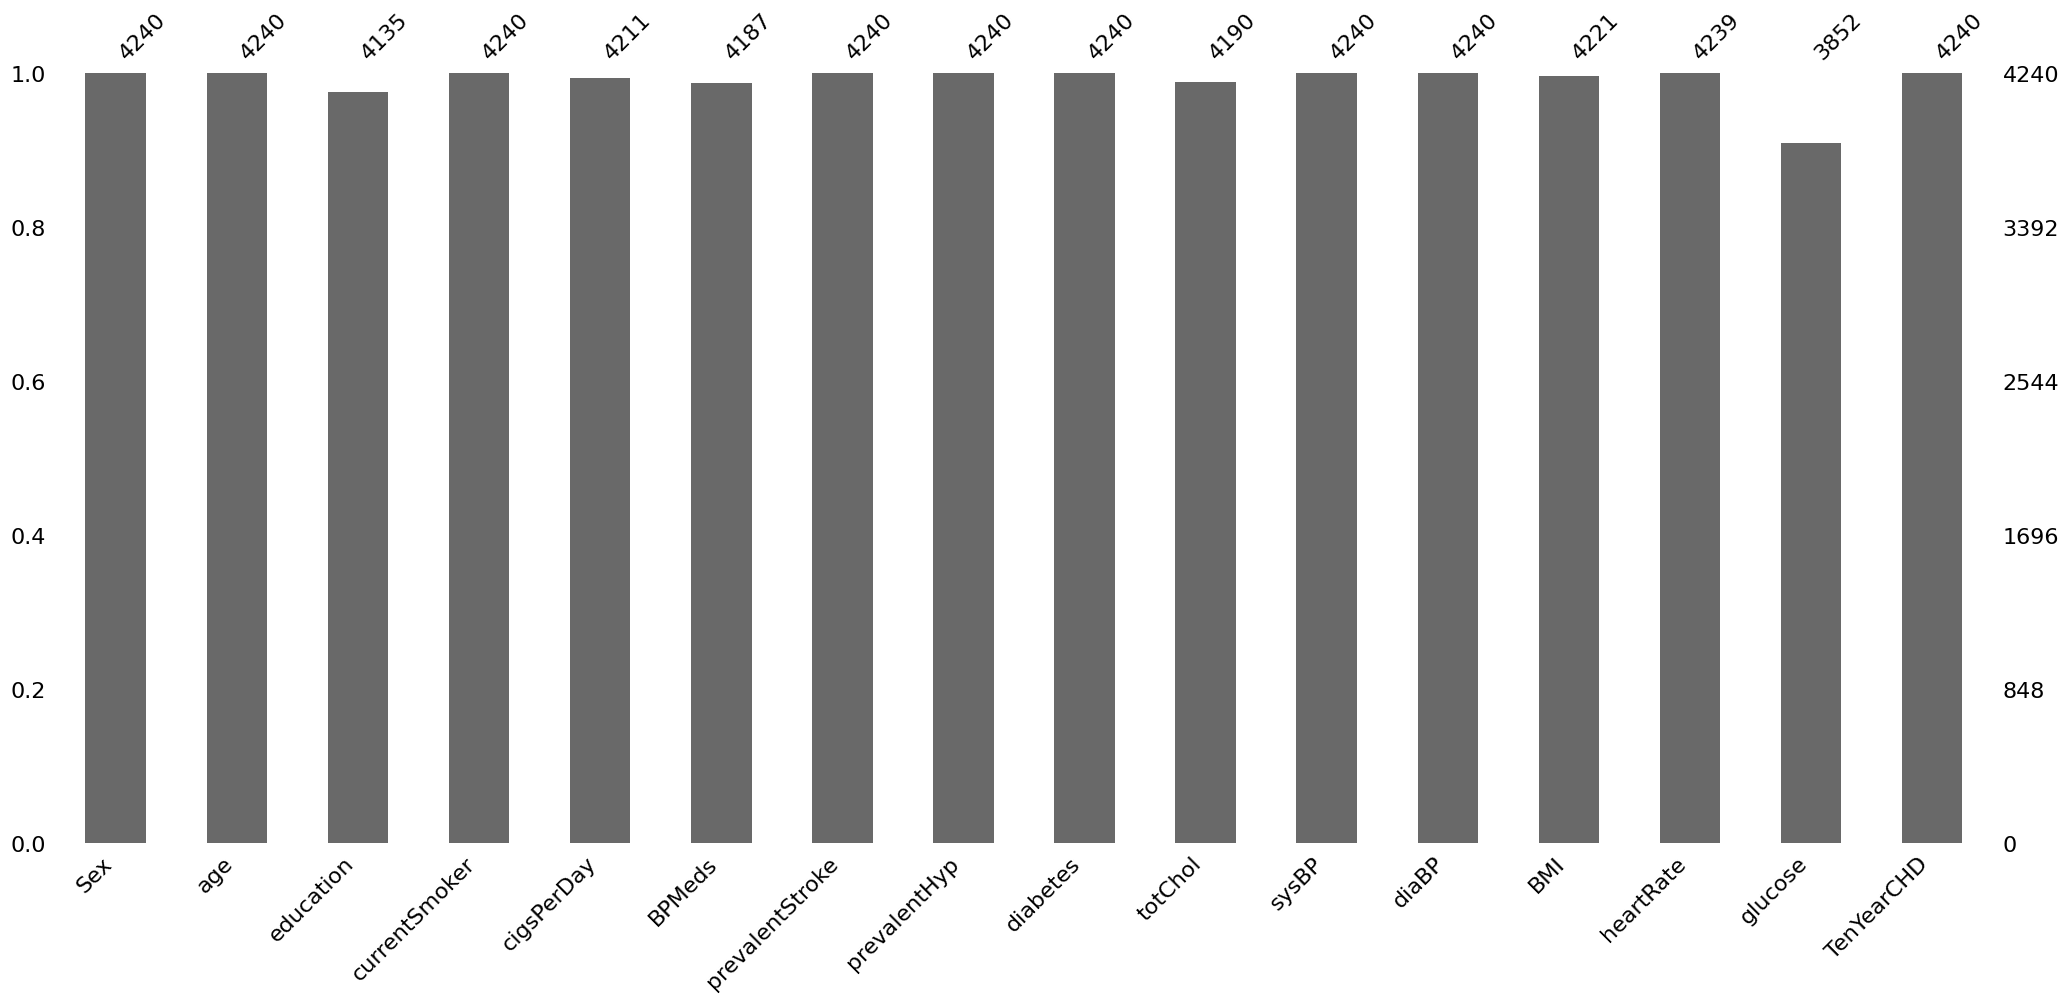

In [12]:
ms.bar(data)

In [13]:
data.isnull().sum()

Sex                  0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [14]:
print('null values percentage', round(data.isna().sum().sum()/len(data.index)*100))

null values percentage 15


In [15]:
data.dropna(axis=0,inplace=True)

In [16]:
data.shape

(3658, 16)

In [18]:
import plotly.express as px

fig = px.histogram(data.Sex, x='Sex', color='Sex', barmode='group', title='gender distribution', width=600, height=400 )

fig.show()

<Axes: >

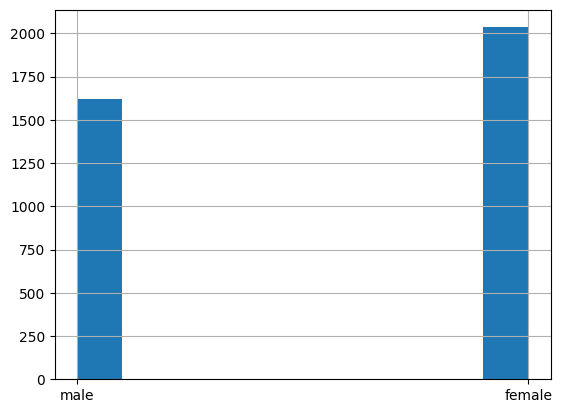

In [19]:
data.Sex.hist()

In [20]:
# Age distribution

[Text(0.5, 1.0, 'age distribution-histogram')]

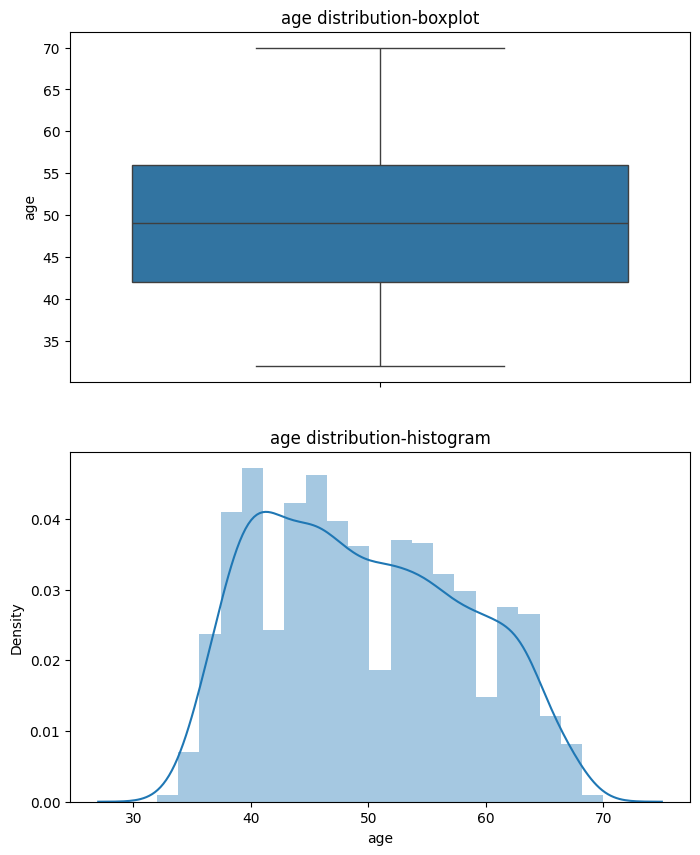

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(nrows=2, figsize=(8,10))
sns.boxplot(data['age'], ax=axs[0]).set(title='age distribution-boxplot')
sns.distplot(data['age'], ax = axs[1]).set(title = 'age distribution-histogram')

In [23]:
fig = px.histogram(data, x='age', color = 'Sex', title = 'Age distribution according to sex', nbins=60, width=600, height=400)

fig.show()

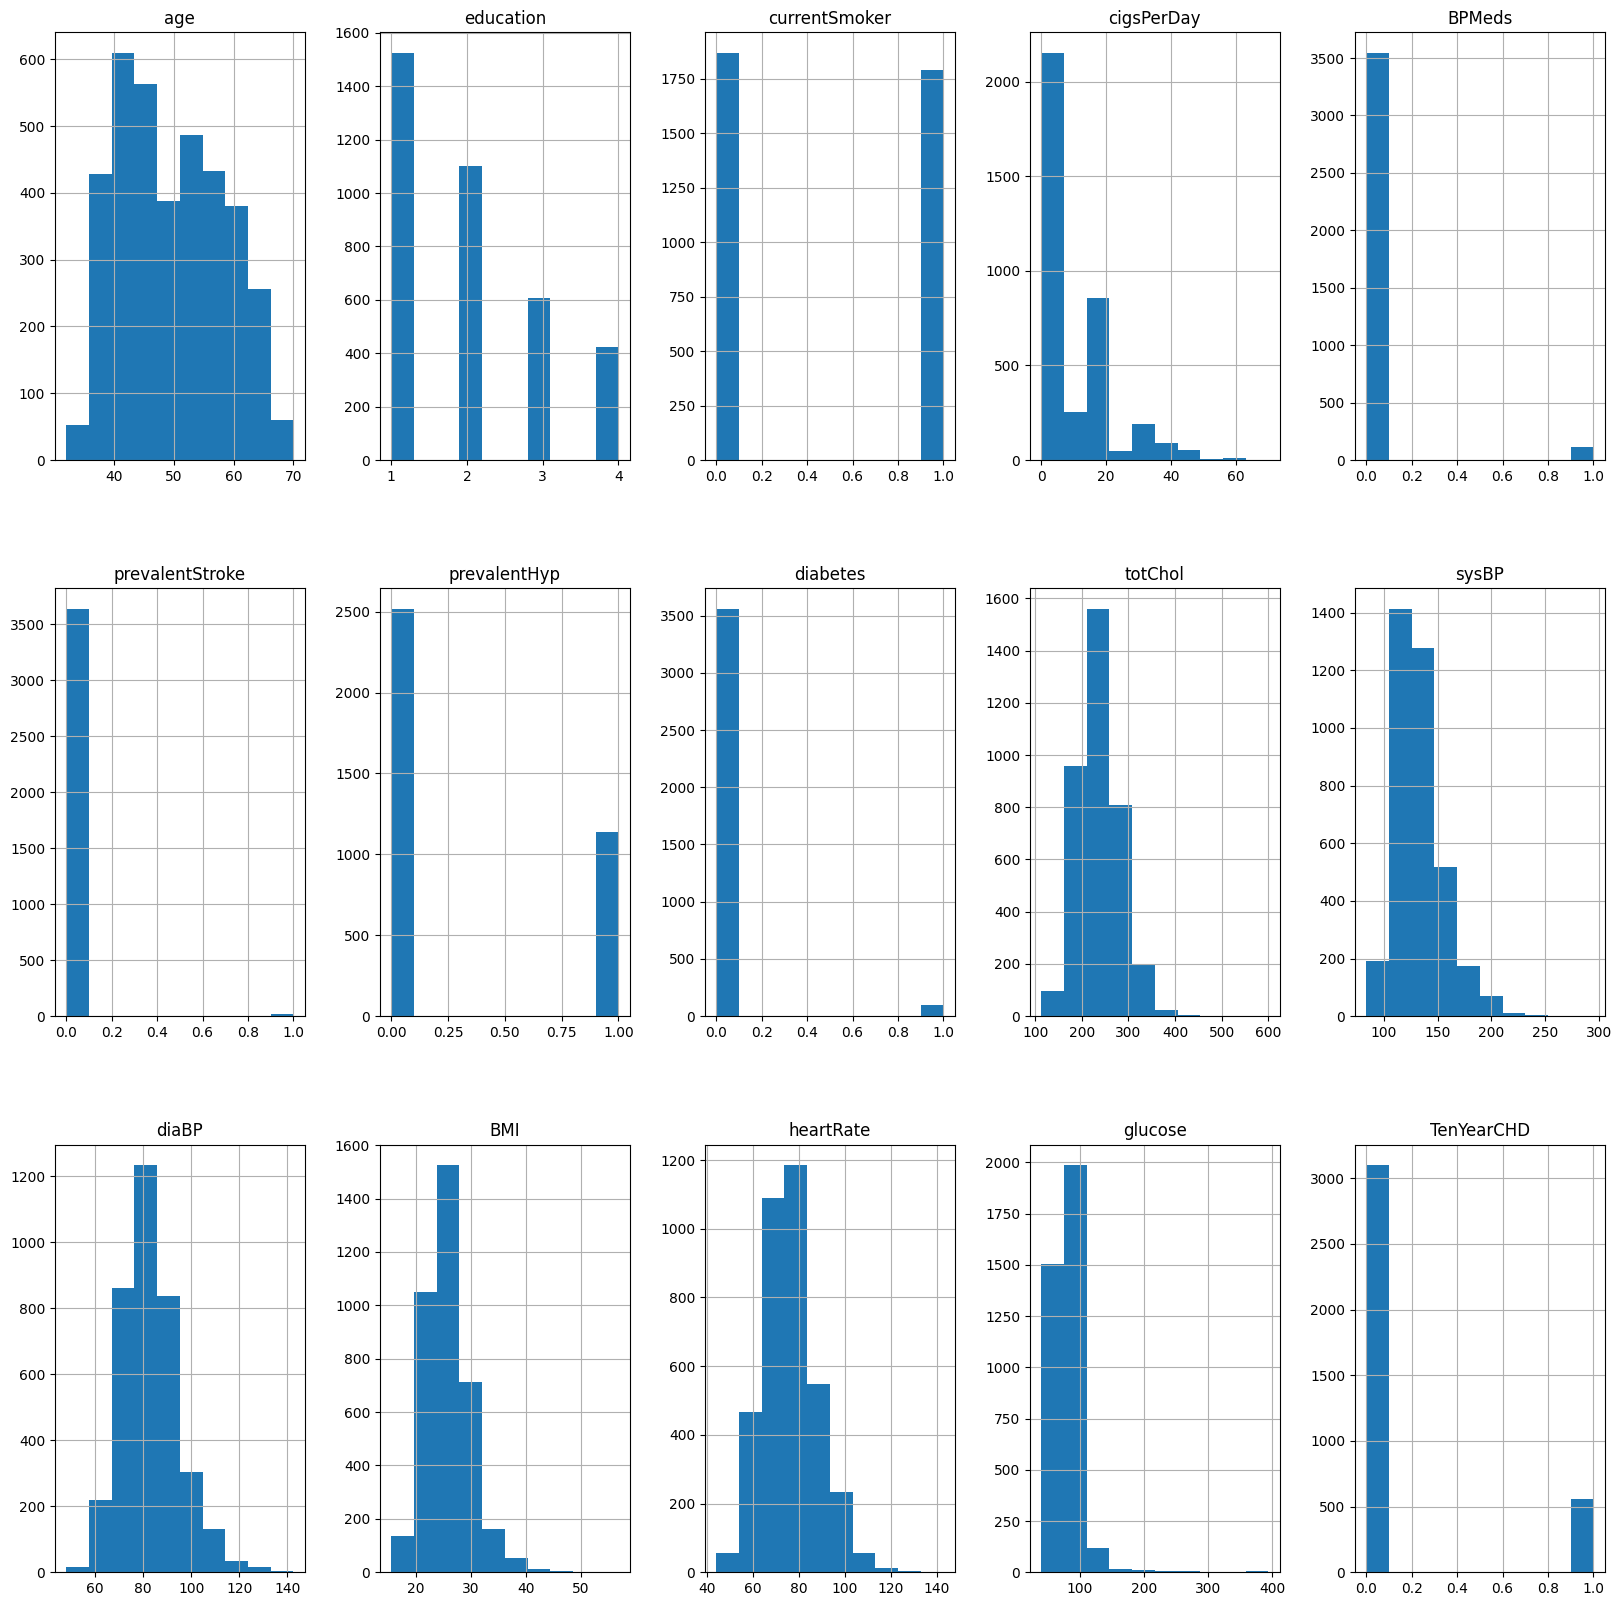

In [25]:
fig, axis = plt.subplots(3,5, figsize=(20,20))

data.hist(ax = axis)

plt.show()

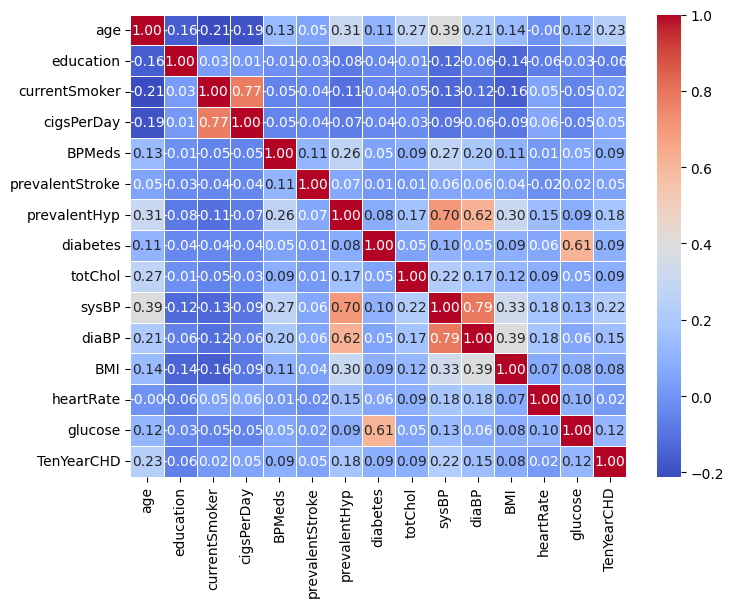

In [32]:
data_corr = data.drop('Sex',axis=1)
corrmat = data_corr.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corrmat, annot=True, cmap='coolwarm', fmt='.2f', linewidth=0.5)
plt.show()

In [28]:
data.head()

,Sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,male,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,female,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,male,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,female,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,female,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
